<a href="https://colab.research.google.com/github/LulutheBA/ANLOK-WATER-PREDICTION-PROJECT-/blob/main/NB4_OP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANLOK Water Prediction Project — Notebook 4
## Machine Learning Modelling, Tuning & Final Evaluation

This notebook connects to the same GitHub repository and consumes Notebook 3 outputs. It produces trained models, predictions, evaluation metrics, visualisations and a model report, then commits and pushes those outputs back to GitHub.

Pipeline: **Notebook 1 → Notebook 2 → Notebook 3 → Notebook 4 → GitHub**.

The project brief requires train/validate/test splitting, model selection and implementation, hyperparameter experiments, training graphs, test results and analysis. The judging criteria also assess model selection, evaluation metrics, modelling/scalability, linkage between findings/data/problem, methodology, and code documentation.

In [21]:
# ============================================================
# IMPORTS
# ============================================================
import os, glob, re, json, shutil, subprocess, warnings
from getpass import getpass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from IPython.display import display
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.base import clone
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error
warnings.filterwarnings('ignore')
print('Libraries imported successfully.')


Libraries imported successfully.


In [22]:
# ============================================================
# PROJECT CONFIGURATION
# ============================================================
PROJECT_ROOT = '/content/ANLOK-WATER-PREDICTION-PROJECT-'
GITHUB_REPO_URL = 'https://github.com/LulutheBA/ANLOK-WATER-PREDICTION-PROJECT-.git'
CLEAN_DATA_DIR = os.path.join(PROJECT_ROOT, 'Outputs', 'CleanData')
DATA_CLEANING_DIR = os.path.join(PROJECT_ROOT, 'Outputs', 'DataCleaning')
EDA_DIR = os.path.join(PROJECT_ROOT, 'Outputs', 'EDA')
FEATURE_ENGINEERING_DIR = os.path.join(PROJECT_ROOT, 'Outputs', 'FeatureEngineering')
MODELLING_DATA_DIR = os.path.join(PROJECT_ROOT, 'Outputs', 'ModellingData')
MODELS_DIR = os.path.join(PROJECT_ROOT, 'Outputs', 'Models')
MODEL_EVALUATION_DIR = os.path.join(PROJECT_ROOT, 'Outputs', 'ModelEvaluation')
PREDICTIONS_DIR = os.path.join(PROJECT_ROOT, 'Outputs', 'Predictions')
MODEL_VISUALISATION_DIR = os.path.join(PROJECT_ROOT, 'Outputs', 'ModelVisualisations')
MODEL_REPORTS_DIR = os.path.join(PROJECT_ROOT, 'Outputs', 'ModelReports')
for d in [MODELS_DIR, MODEL_EVALUATION_DIR, PREDICTIONS_DIR, MODEL_VISUALISATION_DIR, MODEL_REPORTS_DIR]: os.makedirs(d, exist_ok=True)
print('Project root:', PROJECT_ROOT)
print('GitHub:', GITHUB_REPO_URL)


Project root: /content/ANLOK-WATER-PREDICTION-PROJECT-
GitHub: https://github.com/LulutheBA/ANLOK-WATER-PREDICTION-PROJECT-.git


In [23]:
# ============================================================
# CONNECT TO GITHUB AND PULL LATEST VERSION
# ============================================================
if not os.path.isdir(os.path.join(PROJECT_ROOT, '.git')):
    if os.path.exists(PROJECT_ROOT): shutil.rmtree(PROJECT_ROOT)
    r = subprocess.run(['git','clone',GITHUB_REPO_URL,PROJECT_ROOT], capture_output=True, text=True)
    if r.returncode != 0: raise RuntimeError('GitHub clone failed. Check repository access.\n'+r.stderr)
os.chdir(PROJECT_ROOT)
r = subprocess.run(['git','pull','--ff-only'], capture_output=True, text=True)
if r.returncode != 0: raise RuntimeError('Git pull failed.\n'+r.stderr)
for d in [MODELS_DIR, MODEL_EVALUATION_DIR, PREDICTIONS_DIR, MODEL_VISUALISATION_DIR, MODEL_REPORTS_DIR]: os.makedirs(d, exist_ok=True)
print('GitHub repository connected and updated.')


GitHub repository connected and updated.


In [24]:
# ============================================================
# VERIFY NOTEBOOK 2 AND NOTEBOOK 3 HANDOFF
# ============================================================
clean_files = sorted(glob.glob(os.path.join(CLEAN_DATA_DIR, '*.csv')))
if not clean_files: raise FileNotFoundError('No cleaned CSV files found in Outputs/CleanData. Run Notebook 2 and push its results to GitHub.')
candidate_files = []
for d in [MODELLING_DATA_DIR, FEATURE_ENGINEERING_DIR]:
    if os.path.isdir(d): candidate_files.extend(glob.glob(os.path.join(d, '*.csv')))
candidate_files = list(dict.fromkeys(candidate_files))
if not candidate_files: raise FileNotFoundError('No Notebook 3 CSV outputs found. Run Notebook 3 and push its results to GitHub.')
print('Notebook 2 cleaned files:', len(clean_files))
print('Notebook 3 modelling/feature files:', len(candidate_files))
for f in candidate_files: print('  ✓', os.path.relpath(f, PROJECT_ROOT))


Notebook 2 cleaned files: 27
Notebook 3 modelling/feature files: 47
  ✓ Outputs/ModellingData/Drinking_Water_Quality_Compliance_-_SANS_241__2006_-_National__From__2022-07-01_To__2026-06-30__model_ready.csv
  ✓ Outputs/ModellingData/Water_demand_growth__2026_04_21_model_ready.csv
  ✓ Outputs/ModellingData/Surface_Water_Storage__2014-2020__model_ready.csv
  ✓ Outputs/ModellingData/target_candidates.csv
  ✓ Outputs/ModellingData/NIWIS_RWT_16-Jul-2026__model_ready.csv
  ✓ Outputs/ModellingData/Total_Population__2026_04_21_model_ready.csv
  ✓ Outputs/ModellingData/People_Served_with_Water__2026_04_21_model_ready.csv
  ✓ Outputs/ModellingData/Vulnerability_Score_Per_leg__2026_04_21_model_ready.csv
  ✓ Outputs/ModellingData/Potable_Systems__2026_04_21_model_ready.csv
  ✓ Outputs/ModellingData/Operational__2026_04_21_model_ready.csv
  ✓ Outputs/ModellingData/Verified_-_River_Flow___National___model_ready.csv
  ✓ Outputs/ModellingData/Protests_Identified_by_Municipal_IQ__2026_04_21_model_ready.

## Choose the final prediction target

Review the Notebook 3 CSV files above and set the three values in the next cell. Notebook 4 intentionally does **not** guess the target, because the target must directly answer the project's water problem and be defensible in the report.

In [25]:
# ============================================================
# FINAL TARGET CONFIGURATION — ANLOK PRIMARY MODEL
# ============================================================

TARGET_DATASET = 'Weather_engineered'

TARGET_COLUMN = 'rainfall_7day'

PROBLEM_TYPE = 'regression'

EXCLUDE_COLUMNS = [
    'date',
    'time',
    'datetime'
]

RANDOM_STATE = 42

TEST_SIZE = 0.20

VALIDATION_SIZE = 0.20

print("Target dataset :", TARGET_DATASET)
print("Target column  :", TARGET_COLUMN)
print("Problem type   :", PROBLEM_TYPE)
print("Excluded       :", EXCLUDE_COLUMNS)

Target dataset : Weather_engineered
Target column  : rainfall_7day
Problem type   : regression
Excluded       : ['date', 'time', 'datetime']


In [26]:
weather_df_path = next((f for f in candidate_files if 'Weather_engineered.csv' in f), None)
if weather_df_path:
    weather_df = pd.read_csv(weather_df_path)
    print(f"Loaded dataset: {weather_df_path}")
    print("\nDataFrame Info:")
    weather_df.info()
    print("\nFirst 5 rows of the DataFrame:")
    display(weather_df.head())
else:
    print("Weather_engineered.csv not found in candidate files. Please ensure Notebook 3 has been run and its results pushed to GitHub.")

Loaded dataset: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/FeatureEngineering/Weather_engineered.csv

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21301 entries, 0 to 21300
Data columns (total 71 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   station                        21301 non-null  object 
 1   name                           21301 non-null  object 
 2   latitude                       21301 non-null  float64
 3   longitude                      21301 non-null  float64
 4   elevation                      21301 non-null  float64
 5   date                           21301 non-null  object 
 6   prcp                           21301 non-null  float64
 7   prcp_attributes                21301 non-null  object 
 8   tavg                           21301 non-null  float64
 9   tavg_attributes                21301 non-null  object 
 10  tmax                           21301 non-n

,station,name,latitude,longitude,elevation,date,prcp,prcp_attributes,tavg,tavg_attributes,...,rainfall_90day_change,rainfall_90day_pct_change,rainfall_7day_mean_change,rainfall_7day_mean_pct_change,temperature_range_change,temperature_range_pct_change,tmax_7day_mean_change,tmax_7day_mean_pct_change,tmin_7day_mean_change,tmin_7day_mean_pct_change
0,SFM00068368,"JOHANNESBURG INTERNATIONAL, SF",-26.139,28.246,1694.1,2000-01-01,15.5,",,S",17.2,"H,,S",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SFM00068262,"PRETORIA MET, SF",-25.733,28.183,1322.0,2000-01-01,2.3,",,S",21.7,"H,,S",...,2.3,0.148387,-6.600000,-0.425806,-0.2,-0.015267,1.950000,0.072761,2.050,0.149635
2,SFM00068263,"PRETORIA IRENE, SF",-25.917,28.217,1500.0,2000-01-01,1.0,",,S",19.4,"H,,S",...,1.0,0.056180,-2.633333,-0.295880,0.3,0.023256,-0.183333,-0.006377,-0.250,-0.015873
3,SFM00068368,"JOHANNESBURG INTERNATIONAL, SF",-26.139,28.246,1694.1,2000-01-02,0.5,",,S",18.3,"H,,S",...,0.5,0.026596,-1.441667,-0.230053,-1.0,-0.075758,-1.041667,-0.036464,-0.825,-0.053226
4,SFM00068262,"PRETORIA MET, SF",-25.733,28.183,1322.0,2000-01-02,3.0,",,S",22.6,"H,,S",...,3.0,0.155440,-0.365000,-0.075648,-2.3,-0.188525,0.075000,0.002725,0.665,0.045315


Based on the `DataFrame Info` and the `First 5 rows`, choose a column to predict for `TARGET_COLUMN` and specify if it's `regression` or `classification`. Then, update the `TARGET_COLUMN` and `PROBLEM_TYPE` in cell `7h3CnoqmlPX3` and rerun that cell, followed by the subsequent cells to continue with the analysis.

In [27]:
# ============================================================
# LOAD SELECTED DATASET
# ============================================================
if not TARGET_DATASET or not TARGET_COLUMN or PROBLEM_TYPE not in {'regression','classification'}:
    raise ValueError('Set TARGET_DATASET, TARGET_COLUMN and PROBLEM_TYPE before continuing.')
def norm(x): return re.sub(r'[^a-z0-9]+','_',str(x).lower()).strip('_')
matches = [f for f in candidate_files if norm(TARGET_DATASET) in norm(os.path.splitext(os.path.basename(f))[0])]
if not matches:
    print('Available datasets:'); [print(' -', os.path.basename(f)) for f in candidate_files]
    raise FileNotFoundError('Selected target dataset was not found.')
SELECTED_DATASET_PATH = matches[0]
df = pd.read_csv(SELECTED_DATASET_PATH, low_memory=False)
if TARGET_COLUMN not in df.columns:
    print('Available columns:'); [print(' -', c) for c in df.columns]
    raise KeyError(f'Target column {TARGET_COLUMN!r} was not found.')
y = pd.to_numeric(df[TARGET_COLUMN], errors='coerce') if PROBLEM_TYPE=='regression' else df[TARGET_COLUMN]
valid = y.notna(); df = df.loc[valid].copy(); y = y.loc[valid].copy()
print('Dataset:', SELECTED_DATASET_PATH)
print('Shape:', df.shape)
display(df.head())


Dataset: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/FeatureEngineering/Weather_engineered.csv
Shape: (21301, 71)


,station,name,latitude,longitude,elevation,date,prcp,prcp_attributes,tavg,tavg_attributes,...,rainfall_90day_change,rainfall_90day_pct_change,rainfall_7day_mean_change,rainfall_7day_mean_pct_change,temperature_range_change,temperature_range_pct_change,tmax_7day_mean_change,tmax_7day_mean_pct_change,tmin_7day_mean_change,tmin_7day_mean_pct_change
0,SFM00068368,"JOHANNESBURG INTERNATIONAL, SF",-26.139,28.246,1694.1,2000-01-01,15.5,",,S",17.2,"H,,S",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SFM00068262,"PRETORIA MET, SF",-25.733,28.183,1322.0,2000-01-01,2.3,",,S",21.7,"H,,S",...,2.3,0.148387,-6.600000,-0.425806,-0.2,-0.015267,1.950000,0.072761,2.050,0.149635
2,SFM00068263,"PRETORIA IRENE, SF",-25.917,28.217,1500.0,2000-01-01,1.0,",,S",19.4,"H,,S",...,1.0,0.056180,-2.633333,-0.295880,0.3,0.023256,-0.183333,-0.006377,-0.250,-0.015873
3,SFM00068368,"JOHANNESBURG INTERNATIONAL, SF",-26.139,28.246,1694.1,2000-01-02,0.5,",,S",18.3,"H,,S",...,0.5,0.026596,-1.441667,-0.230053,-1.0,-0.075758,-1.041667,-0.036464,-0.825,-0.053226
4,SFM00068262,"PRETORIA MET, SF",-25.733,28.183,1322.0,2000-01-02,3.0,",,S",22.6,"H,,S",...,3.0,0.155440,-0.365000,-0.075648,-2.3,-0.188525,0.075000,0.002725,0.665,0.045315


In [28]:
# ============================================================
# PREPARE FEATURES
# ============================================================
X = df.drop(columns=[TARGET_COLUMN] + [c for c in EXCLUDE_COLUMNS if c in df.columns], errors='ignore').copy()
for col in list(X.columns):
    if pd.api.types.is_datetime64_any_dtype(X[col]): parsed = X[col]
    elif X[col].dtype == 'object':
        sample = X[col].dropna().head(100)
        if len(sample)==0: continue
        ps = pd.to_datetime(sample, errors='coerce')
        if ps.notna().mean() < .80: continue
        parsed = pd.to_datetime(X[col], errors='coerce')
    else: continue
    X[f'{col}_year']=parsed.dt.year; X[f'{col}_month']=parsed.dt.month; X[f'{col}_day']=parsed.dt.day; X[f'{col}_dayofyear']=parsed.dt.dayofyear
    X.drop(columns=[col], inplace=True)
print('Features:', X.shape)


Features: (21301, 69)


In [29]:
# ============================================================
# TRAIN / VALIDATION / TEST SPLIT
# TIME-AWARE SPLIT FOR RAINFALL FORECASTING
# ============================================================

print("=" * 90)
print("TIME-AWARE TRAIN / VALIDATION / TEST SPLIT")
print("=" * 90)

# ------------------------------------------------------------
# Identify the date column
# ------------------------------------------------------------

date_candidates = [
    "date",
    "datetime",
    "time"
]

date_column = None

for col in date_candidates:
    if col in df.columns:
        date_column = col
        break

if date_column is None:
    raise KeyError(
        "No date/datetime column was found. "
        "A chronological split is required for rainfall forecasting."
    )

# ------------------------------------------------------------
# Convert date column
# ------------------------------------------------------------

df["_model_date"] = pd.to_datetime(
    df[date_column],
    errors="coerce"
)

# Remove rows where date could not be interpreted
valid_dates = df["_model_date"].notna()

df = df.loc[valid_dates].copy()

# Re-create target after filtering
if PROBLEM_TYPE == "regression":
    y = pd.to_numeric(
        df[TARGET_COLUMN],
        errors="coerce"
    )
else:
    y = df[TARGET_COLUMN]

valid_target = y.notna()

df = df.loc[valid_target].copy()
y = y.loc[valid_target].copy()

# ------------------------------------------------------------
# Sort chronologically
# ------------------------------------------------------------

df = df.sort_values(
    "_model_date"
).reset_index(drop=True)

y = y.loc[df.index].reset_index(drop=True)

# ------------------------------------------------------------
# Create X
# ------------------------------------------------------------

X = df.drop(
    columns=[
        TARGET_COLUMN,
        "_model_date"
    ] + [
        c for c in EXCLUDE_COLUMNS
        if c in df.columns
    ],
    errors="ignore"
).copy()

# ------------------------------------------------------------
# Calculate split positions
# ------------------------------------------------------------

n = len(X)

test_start = int(
    n * (1 - TEST_SIZE)
)

validation_start = int(
    n * (1 - TEST_SIZE - VALIDATION_SIZE)
)

# ------------------------------------------------------------
# Split chronologically
# ------------------------------------------------------------

X_train = X.iloc[
    :validation_start
].copy()

y_train = y.iloc[
    :validation_start
].copy()

X_validation = X.iloc[
    validation_start:test_start
].copy()

y_validation = y.iloc[
    validation_start:test_start
].copy()

X_test = X.iloc[
    test_start:
].copy()

y_test = y.iloc[
    test_start:
].copy()

# ------------------------------------------------------------
# Full training data for final model
# ------------------------------------------------------------

X_train_full = pd.concat(
    [
        X_train,
        X_validation
    ],
    axis=0
)

y_train_full = pd.concat(
    [
        y_train,
        y_validation
    ],
    axis=0
)

# ------------------------------------------------------------
# Display split information
# ------------------------------------------------------------

print()
print("Chronological split completed.")
print()

print(
    f"Training observations   : {len(X_train):,}"
)

print(
    f"Validation observations : {len(X_validation):,}"
)

print(
    f"Testing observations    : {len(X_test):,}"
)

print()

print(
    "Training period:"
)

print(
    df["_model_date"].iloc[0],
    "→",
    df["_model_date"].iloc[
        validation_start - 1
    ]
)

print()

print(
    "Validation period:"
)

print(
    df["_model_date"].iloc[
        validation_start
    ],
    "→",
    df["_model_date"].iloc[
        test_start - 1
    ]
)

print()

print(
    "Testing period:"
)

print(
    df["_model_date"].iloc[
        test_start
    ],
    "→",
    df["_model_date"].iloc[-1]
)

print()

print(
    "No future observations are used to train the model."
)

TIME-AWARE TRAIN / VALIDATION / TEST SPLIT

Chronological split completed.

Training observations   : 12,780
Validation observations : 4,260
Testing observations    : 4,261

Training period:
2000-01-01 00:00:00 → 2012-02-09 00:00:00

Validation period:
2012-02-09 00:00:00 → 2016-09-01 00:00:00

Testing period:
2016-09-01 00:00:00 → 2025-08-24 00:00:00

No future observations are used to train the model.


In [30]:
# ============================================================
# PREPROCESSING
# ============================================================
num=list(X_train.select_dtypes(include=np.number).columns); cat=list(X_train.select_dtypes(exclude=np.number).columns)
preprocessor=ColumnTransformer([('num',Pipeline([('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler())]),num),('cat',Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore'))]),cat)])
print('Numeric features:',len(num)); print('Categorical features:',len(cat))


Numeric features: 63
Categorical features: 6


In [31]:
# ============================================================
# BASELINE MODELS
# ============================================================
if PROBLEM_TYPE=='regression':
    models={'Linear Regression':LinearRegression(),'Ridge Regression':Ridge(alpha=1.0),'Random Forest':RandomForestRegressor(n_estimators=300,random_state=RANDOM_STATE,n_jobs=-1),'Extra Trees':ExtraTreesRegressor(n_estimators=300,random_state=RANDOM_STATE,n_jobs=-1),'Gradient Boosting':GradientBoostingRegressor(random_state=RANDOM_STATE)}
else:
    models={'Logistic Regression':LogisticRegression(max_iter=2000,random_state=RANDOM_STATE),'Random Forest':RandomForestClassifier(n_estimators=300,random_state=RANDOM_STATE,n_jobs=-1,class_weight='balanced'),'Extra Trees':ExtraTreesClassifier(n_estimators=300,random_state=RANDOM_STATE,n_jobs=-1,class_weight='balanced'),'Gradient Boosting':GradientBoostingClassifier(random_state=RANDOM_STATE)}
results=[]; fitted={}
for name,est in models.items():
    pipe=Pipeline([('preprocessor',preprocessor),('model',est)])
    try:
        pipe.fit(X_train,y_train); pred=pipe.predict(X_validation); fitted[name]=pipe
        if PROBLEM_TYPE=='classification':
            row={'Model':name,'Accuracy':accuracy_score(y_validation,pred),'Precision':precision_score(y_validation,pred,average='weighted',zero_division=0),'Recall':recall_score(y_validation,pred,average='weighted',zero_division=0),'F1':f1_score(y_validation,pred,average='weighted',zero_division=0)}
            try:
                p=pipe.predict_proba(X_validation); row['ROC_AUC']=roc_auc_score(y_validation,p[:,1]) if p.shape[1]==2 else roc_auc_score(y_validation,p,multi_class='ovr',average='weighted')
            except: row['ROC_AUC']=np.nan
        else:
            row={'Model':name,'MAE':mean_absolute_error(y_validation,pred),'RMSE':np.sqrt(mean_squared_error(y_validation,pred)),'R2':r2_score(y_validation,pred)}
            try: row['MAPE']=mean_absolute_percentage_error(y_validation,pred)
            except: row['MAPE']=np.nan
        results.append(row)
    except Exception as e: print(name,'FAILED:',e)
baseline_df=pd.DataFrame(results)
if baseline_df.empty: raise RuntimeError('All baseline models failed.')
display(baseline_df)
baseline_df.to_csv(os.path.join(MODEL_EVALUATION_DIR,'baseline_model_comparison.csv'),index=False)


,Model,MAE,RMSE,R2,MAPE
0,Linear Regression,1.670431,8.868528,0.909332,0.162328
1,Ridge Regression,1.666013,8.872268,0.909255,0.160477
2,Random Forest,2.222607,10.202576,0.880003,0.184562
3,Extra Trees,1.929011,9.638666,0.892901,0.133482
4,Gradient Boosting,1.922428,9.728180,0.890902,0.130311


In [32]:
# ============================================================
# SELECT + TUNE BEST BASELINE
# ============================================================
if PROBLEM_TYPE=='classification': best_name=baseline_df.sort_values('F1',ascending=False).iloc[0]['Model']; scoring='f1_weighted'
else: best_name=baseline_df.sort_values('RMSE',ascending=True).iloc[0]['Model']; scoring='neg_root_mean_squared_error'
grids={'Linear Regression':{},'Ridge Regression':{'model__alpha':[.01,.1,1,10,100]},'Random Forest':{'model__n_estimators':[200,300],'model__max_depth':[None,10,20],'model__min_samples_split':[2,5]},'Extra Trees':{'model__n_estimators':[200,300],'model__max_depth':[None,10,20],'model__min_samples_split':[2,5]},'Gradient Boosting':{'model__n_estimators':[100,200],'model__learning_rate':[.03,.05,.1],'model__max_depth':[2,3,5]},'Logistic Regression':{'model__C':[.01,.1,1,10,100]}}
grid=grids.get(best_name,{})
if grid:
    search=GridSearchCV(Pipeline([('preprocessor',preprocessor),('model',clone(models[best_name]))]),grid,cv=5,scoring=scoring,n_jobs=-1,refit=True)
    search.fit(X_train_full,y_train_full); final_model=search.best_estimator_
    pd.DataFrame(search.cv_results_).to_csv(os.path.join(MODEL_EVALUATION_DIR,'hyperparameter_tuning_results.csv'),index=False)
    print('Best model:',best_name); print('Best parameters:',search.best_params_); print('Best CV score:',search.best_score_)
else:
    search=None; final_model=fitted[best_name]
    print('Best model:',best_name,'(no tuning grid configured)')


Best model: Linear Regression (no tuning grid configured)


In [33]:
# ============================================================
# FINAL TEST EVALUATION
# ============================================================
pred=final_model.predict(X_test)
if PROBLEM_TYPE=='classification':
    metrics={'Dataset':TARGET_DATASET,'Target':TARGET_COLUMN,'Problem_Type':PROBLEM_TYPE,'Model':best_name,'Accuracy':accuracy_score(y_test,pred),'Precision':precision_score(y_test,pred,average='weighted',zero_division=0),'Recall':recall_score(y_test,pred,average='weighted',zero_division=0),'F1':f1_score(y_test,pred,average='weighted',zero_division=0),'Test_Rows':len(y_test)}
    try:
        p=final_model.predict_proba(X_test); metrics['ROC_AUC']=roc_auc_score(y_test,p[:,1]) if p.shape[1]==2 else roc_auc_score(y_test,p,multi_class='ovr',average='weighted')
    except: metrics['ROC_AUC']=np.nan
    print(classification_report(y_test,pred,zero_division=0))
else:
    metrics={'Dataset':TARGET_DATASET,'Target':TARGET_COLUMN,'Problem_Type':PROBLEM_TYPE,'Model':best_name,'MAE':mean_absolute_error(y_test,pred),'RMSE':np.sqrt(mean_squared_error(y_test,pred)),'R2':r2_score(y_test,pred),'Test_Rows':len(y_test)}
    try: metrics['MAPE']=mean_absolute_percentage_error(y_test,pred)
    except: metrics['MAPE']=np.nan
final_metrics_df=pd.DataFrame([metrics]); display(final_metrics_df)
final_metrics_df.to_csv(os.path.join(MODEL_EVALUATION_DIR,'final_test_metrics.csv'),index=False)


,Dataset,Target,Problem_Type,Model,MAE,RMSE,R2,Test_Rows,MAPE
0,Weather_engineered,rainfall_7day,regression,Linear Regression,0.966206,3.14669,0.977521,4261,0.139103


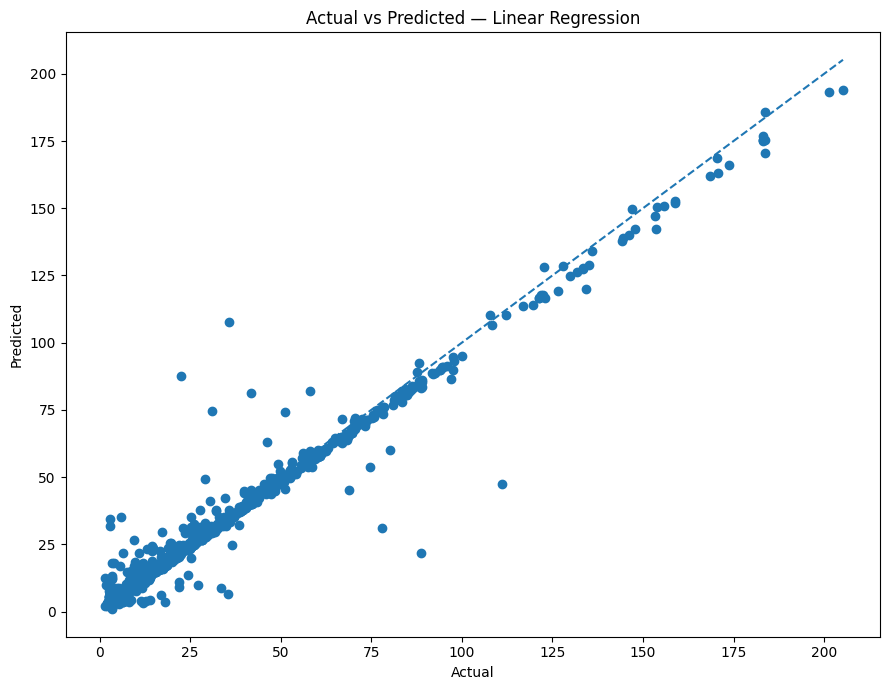

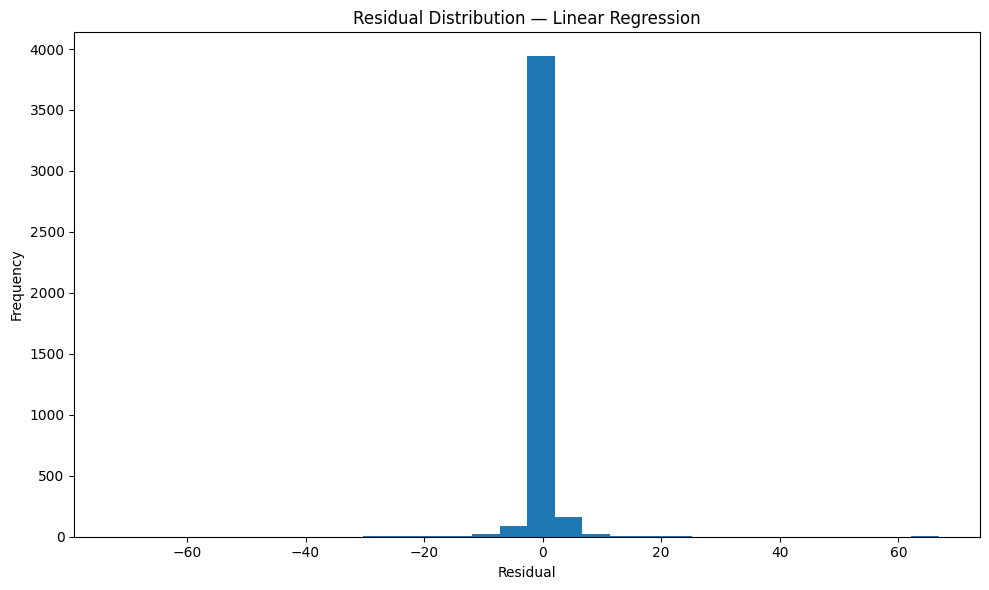

In [34]:
# ============================================================
# SAVE PREDICTIONS + VISUALISATIONS
# ============================================================
pred_df=pd.DataFrame({'Actual':np.asarray(y_test),'Predicted':np.asarray(pred)})
if PROBLEM_TYPE=='regression':
    pred_df['Residual']=pred_df['Actual']-pred_df['Predicted']
    plt.figure(figsize=(9,7)); plt.scatter(pred_df.Actual,pred_df.Predicted); lo=min(pred_df.Actual.min(),pred_df.Predicted.min()); hi=max(pred_df.Actual.max(),pred_df.Predicted.max()); plt.plot([lo,hi],[lo,hi],linestyle='--'); plt.title(f'Actual vs Predicted — {best_name}'); plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.tight_layout(); plt.savefig(os.path.join(MODEL_VISUALISATION_DIR,'actual_vs_predicted.png'),dpi=300,bbox_inches='tight'); plt.show(); plt.close()
    plt.figure(figsize=(10,6)); plt.hist(pred_df.Residual.dropna(),bins=30); plt.title(f'Residual Distribution — {best_name}'); plt.xlabel('Residual'); plt.ylabel('Frequency'); plt.tight_layout(); plt.savefig(os.path.join(MODEL_VISUALISATION_DIR,'residual_distribution.png'),dpi=300,bbox_inches='tight'); plt.show(); plt.close()
else:
    labels=np.unique(np.concatenate([np.asarray(y_test),np.asarray(pred)])); cm=confusion_matrix(y_test,pred,labels=labels); plt.figure(figsize=(9,7)); plt.imshow(cm,aspect='auto'); plt.title(f'Confusion Matrix — {best_name}'); plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.xticks(range(len(labels)),labels,rotation=45,ha='right'); plt.yticks(range(len(labels)),labels); [plt.text(j,i,str(cm[i,j]),ha='center',va='center') for i in range(cm.shape[0]) for j in range(cm.shape[1])]; plt.tight_layout(); plt.savefig(os.path.join(MODEL_VISUALISATION_DIR,'confusion_matrix.png'),dpi=300,bbox_inches='tight'); plt.show(); plt.close()
pred_df.to_csv(os.path.join(PREDICTIONS_DIR,'test_predictions.csv'),index=False)


In [35]:
# ============================================================
# FEATURE IMPORTANCE (TREE MODELS)
# ============================================================
model_step=final_model.named_steps['model']
if hasattr(model_step,'feature_importances_'):
    names=final_model.named_steps['preprocessor'].get_feature_names_out(); imp=pd.DataFrame({'Feature':names,'Importance':model_step.feature_importances_}).sort_values('Importance',ascending=False); imp.to_csv(os.path.join(MODEL_EVALUATION_DIR,'feature_importance.csv'),index=False); top=imp.head(20).sort_values('Importance'); plt.figure(figsize=(10,8)); plt.barh(top.Feature,top.Importance); plt.title(f'Top Feature Importances — {best_name}'); plt.xlabel('Importance'); plt.tight_layout(); plt.savefig(os.path.join(MODEL_VISUALISATION_DIR,'feature_importance.png'),dpi=300,bbox_inches='tight'); plt.show(); plt.close(); display(imp.head(20))


In [36]:
# ============================================================
# SAVE MODEL + REPORT
# ============================================================
safe=re.sub(r'[^A-Za-z0-9_.-]','_',f'{TARGET_DATASET}_{TARGET_COLUMN}_{best_name}')
model_path=os.path.join(MODELS_DIR,f'{safe}.joblib'); joblib.dump(final_model,model_path)
metadata={'project':'ANLOK Water Prediction Project','notebook':'Notebook 4','dataset':TARGET_DATASET,'target':TARGET_COLUMN,'problem_type':PROBLEM_TYPE,'model':best_name,'random_state':RANDOM_STATE,'train_rows':len(X_train),'validation_rows':len(X_validation),'test_rows':len(X_test),'feature_count':X.shape[1]}
if search is not None: metadata['best_parameters']=search.best_params_
with open(os.path.join(MODEL_REPORTS_DIR,'model_metadata.json'),'w') as f: json.dump(metadata,f,indent=4,default=str)
report=['# ANLOK Water Prediction Project — Notebook 4 Model Report','',f'- Dataset: {TARGET_DATASET}',f'- Target: {TARGET_COLUMN}',f'- Problem type: {PROBLEM_TYPE}',f'- Final model: {best_name}','',f'- Training rows: {len(X_train):,}',f'- Validation rows: {len(X_validation):,}',f'- Test rows: {len(X_test):,}','', '## Final test results']+[f'- {k}: {v}' for k,v in metrics.items()]
with open(os.path.join(MODEL_REPORTS_DIR,'model_report.md'),'w') as f: f.write('\n'.join(report))
print('Saved model:',model_path)
0

Saved model: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/Models/Weather_engineered_rainfall_7day_Linear_Regression.joblib


0

In [37]:
1# ============================================================
# COMMIT + PUSH NOTEBOOK 4 RESULTS TO GITHUB
# ============================================================
os.chdir(PROJECT_ROOT)
subprocess.run(['git','config','user.name','LulutheBA'],check=False)
subprocess.run(['git','config','user.email','lulutheba@users.noreply.github.com'],check=False)
subprocess.run(['git','add','-A','Outputs/Models','Outputs/ModelEvaluation','Outputs/Predictions','Outputs/ModelVisualisations','Outputs/ModelReports'],check=True)
status=subprocess.run(['git','status','--short'],capture_output=True,text=True)
print(status.stdout or 'No new changes.')
if status.stdout.strip():
    commit=subprocess.run(['git','commit','-m','Add Notebook 4 machine learning models and evaluation results'],capture_output=True,text=True)
    if commit.returncode!=0: raise RuntimeError(commit.stderr)
    print(commit.stdout)
print('Enter GitHub credentials. Your token is not saved in the repository.')
username=input('GitHub username: ').strip()
token=getpass('GitHub Personal Access Token: ').strip()
if not username or not token: raise RuntimeError('GitHub username and token are required.')

# Store the token temporarily before clearing it
temp_token = token

# Construct the temporary remote URL with the token
# This is a common way to authenticate non-interactively with git HTTPS remotes
# GITHUB_REPO_URL is defined in cell AidoS-PxlPX0 as 'https://github.com/LulutheBA/ANLOK-WATER-PREDICTION-PROJECT-.git'
token_embedded_url = GITHUB_REPO_URL.replace('https://', f'https://{username}:{temp_token}@')

# Set the remote origin URL to include the token
set_url_cmd = subprocess.run(['git', 'remote', 'set-url', 'origin', token_embedded_url], capture_output=True, text=True)
if set_url_cmd.returncode != 0:
    raise RuntimeError(f"Failed to set temporary remote URL for push.\n{set_url_cmd.stderr}")

# Perform the push without the 'input' argument, as credentials are now in the URL
push=subprocess.run(['git','push','origin','HEAD'],capture_output=True,text=True)

# Reset the remote origin URL back to its original form (without the token) for security
reset_url_cmd = subprocess.run(['git', 'remote', 'set-url', 'origin', GITHUB_REPO_URL], capture_output=True, text=True)
if reset_url_cmd.returncode != 0:
    # This is a non-critical error for the push itself, but important for security.
    # Log it, but don't stop execution unless the original push failed.
    print(f"Warning: Failed to reset remote URL to original form.\n{reset_url_cmd.stderr}")

token='' # Clear the token variable immediately after use for security

if push.returncode!=0: raise RuntimeError('GitHub push failed. Confirm the token has repository Contents: Read and write permission.\n'+push.stderr)
print(push.stdout)
print('SUCCESS — Notebook 4 results pushed to GitHub.')


M  Outputs/ModelEvaluation/baseline_model_comparison.csv
M  Outputs/ModelEvaluation/final_test_metrics.csv
M  Outputs/ModelReports/model_metadata.json
M  Outputs/ModelReports/model_report.md
M  Outputs/ModelVisualisations/actual_vs_predicted.png
M  Outputs/ModelVisualisations/residual_distribution.png
M  Outputs/Models/Weather_engineered_rainfall_7day_Linear_Regression.joblib
M  Outputs/Predictions/test_predictions.csv

[main a0d8e37] Add Notebook 4 machine learning models and evaluation results
 8 files changed, 4274 insertions(+), 4274 deletions(-)
 rewrite Outputs/ModelEvaluation/baseline_model_comparison.csv (95%)
 rewrite Outputs/ModelVisualisations/actual_vs_predicted.png (97%)
 rewrite Outputs/ModelVisualisations/residual_distribution.png (95%)
 rewrite Outputs/Models/Weather_engineered_rainfall_7day_Linear_Regression.joblib (67%)
 rewrite Outputs/Predictions/test_predictions.csv (96%)

Enter GitHub credentials. Your token is not saved in the repository.
GitHub username: Luluthe

In [38]:
# ============================================================
# COMPLETION SUMMARY
# ============================================================
print('='*90); print('NOTEBOOK 4 COMPLETE'); print('='*90)
print('Input: Outputs/ModellingData/ or Outputs/FeatureEngineering/')
print('Model:',best_name); print('Target:',TARGET_COLUMN); print('Problem type:',PROBLEM_TYPE)
print('Models: Outputs/Models/'); print('Evaluation: Outputs/ModelEvaluation/'); print('Predictions: Outputs/Predictions/'); print('Visualisations: Outputs/ModelVisualisations/'); print('Reports: Outputs/ModelReports/')
print('All Notebook 4 outputs were pushed to GitHub.')

NOTEBOOK 4 COMPLETE
Input: Outputs/ModellingData/ or Outputs/FeatureEngineering/
Model: Linear Regression
Target: rainfall_7day
Problem type: regression
Models: Outputs/Models/
Evaluation: Outputs/ModelEvaluation/
Predictions: Outputs/Predictions/
Visualisations: Outputs/ModelVisualisations/
Reports: Outputs/ModelReports/
All Notebook 4 outputs were pushed to GitHub.
